In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import importlib
import benchmarks
import itertools
import h5py
import glob
import os
import sys
import matplotlib.ticker as mticker
import matplotlib.pylab as pylab
params = {'figure.titlesize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}

pylab.rcParams.update(params)
importlib.reload(benchmarks)

<module 'benchmarks' from '/storage/home/hcodaman1/rtat3/Spin-tracking/benchmarks/benchmarks.py'>

In [8]:
def get_formatter():
    formatter = mticker.ScalarFormatter(useMathText=True)  # Ensures 'e' notation instead of '10^x'
    formatter.set_scientific(True)  # Keep scientific notation
    formatter.set_powerlimits((-1, 1))  # Defines when scientific notation should be used
    return formatter

In [9]:
physics = {'B0' : '5e-6, 0, 0',
           'L' : '1.0, 1.0, 1.0',
           'yi' : '0.0, 0.0, 1.0',
           'm' : '1.20239e-26',
           't0' : '0.0',
           'tf' : '1.0',
           'gamma' : '-2.038e8',
           'a' : '0.0',
           'w' : '6.28318530718e3',
           'diffuse' : '0.0',
           'gas_coll' : 'true',
           'gravity' : 'false',
           'dist' : 'M'}

integration = {'numParticles' : '8192',
               'numPerGPUBlock' : '256',
               'integratorType' : '6',
               'seed' : 'rand',
               'h': '1e-4'}

scratch_dir = '/storage/home/hcodaman1/rtat3/scratch'

In [10]:
if os.path.isdir('/usr/local/pace-apps/lmod/lmod/init/'):
    # Specifically for the PACE cluster
    sys.path.append('/usr/local/pace-apps/lmod/lmod/init/')
    from env_modules_python import module
    module('load', 'nvhpc', 'gcc', 'openmpi', 'cuda', 'hdf5')


Lmod is automatically replacing "gcc/12.3.0" with "nvhpc-nvc/24.5".


Lmod is automatically replacing "nvhpc-nvc/24.5" with "gcc/12.3.0".




In [11]:
def smooth_theory(x, y, kind='quadratic', num=50):
    fit_func = interp1d(pred_x, pred_y, kind=kind)
    xres = np.linspace(min(x), max(x), num=num)
    return xres, fit_func(xres)

In [12]:
B2_folder = 'B2_benchmark'
E2_folder = 'E2_benchmark'

In [7]:
E_range = np.linspace(0, 1e7, num=5)
Gzz_range = np.linspace(0, 3e-9, num=5)
T_range = [0.25]
for _ in range(16):
    for (iType, ioutInt) in [('0', '1.0'), ('6', '1.0'), ('7', '1.0')]:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                            E_range = E_range,
                                            T_range = T_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, E2_folder))
        pb.run()
        pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                            Gzz_range = Gzz_range,
                                            T_range = T_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, B2_folder))
        pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 771
{0, -0.901827, 0.432096}
1458
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 716
{3.01688e-05, -0.90183, 0.432088}
1045
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 682
{-5.14052e-05, -0.901838, 0.432062}
917
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 680
{1.27267e-05, -0.90185, 0.432019}
909
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 683
{-0.00017192, -0.901868, 0.431959}
919
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 

iter 0, duration 0, 6
iter 1, duration 1, 2399
{4.86583e-13, -0.901827, 0.432096}
2642
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 5
iter 1, duration 1, 2432
{4.865e-13, -0.901828, 0.432096}
2670
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2412
{4.86694e-13, -0.901829, 0.432093}
2648
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2400
{4.86694e-13, -0.901831, 0.432088}
2639
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2431
{4.86639e-13, -0.901833, 0.432082}
2671
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 100
iter 1, duration 1, 137
{4.86583e-13, -0.901827, 0.432096}
902


iter 0, duration 0, 11
iter 1, duration 1, 695
{0, -0.901827, 0.432096}
924
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 673
{-2.96893e-05, -0.90183, 0.432088}
912
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 682
{1.45375e-07, -0.901837, 0.432062}
915
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 683
{1.29786e-05, -0.90185, 0.432019}
1239
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 693
{2.22751e-05, -0.901868, 0.431958}
924
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 701
{0, -0.901827, 0.432096}
931
 
Knudsen Number: 1.55e-

{4.86583e-13, -0.901827, 0.432096}
2702
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2403
{4.86639e-13, -0.901828, 0.432096}
2646
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2404
{4.86639e-13, -0.901829, 0.432093}
2642
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2372
{4.86639e-13, -0.901831, 0.432088}
2615
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2387
{4.8675e-13, -0.901833, 0.432082}
2632
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 100
iter 1, duration 1, 138
{4.86583e-13, -0.901827, 0.432096}
682
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e

{0, -0.901827, 0.432096}
930
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 681
{-3.29976e-05, -0.90183, 0.432088}
936
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 679
{1.20595e-05, -0.901838, 0.432062}
920
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 679
{3.25548e-05, -0.90185, 0.432019}
918
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 673
{6.40433e-05, -0.901868, 0.431959}
906
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 687
{0, -0.901827, 0.432096}
920
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regi

...

iter 0, duration 0, 12
iter 1, duration 1, 680
{-2.39531e-05, -0.90183, 0.432088}
914
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 683
{-3.16702e-06, -0.901838, 0.432062}
914
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 676
{-0.00014647, -0.90185, 0.432019}
915
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 678
{3.49978e-06, -0.901868, 0.431959}
913
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 698
{0, -0.901827, 0.432096}
949
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 689
{5.97703e-07, -0.901828, 0.432096}
920
 
Knudsen Numb

iter 1, duration 1, 2417
{4.8675e-13, -0.901828, 0.432096}
2656
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 5
iter 1, duration 1, 2410
{4.86639e-13, -0.901829, 0.432093}
2677
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2370
{4.86555e-13, -0.901831, 0.432088}
2612
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2417
{4.86722e-13, -0.901833, 0.432082}
2656
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 101
iter 1, duration 1, 137
{4.86583e-13, -0.901827, 0.432096}
676
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 100
iter 1, duration 1, 119
{4.86722e-13, -0.90183, 0.432088}
658
 
Knudsen Number: 1.55

{2.85325e-05, -0.90183, 0.432088}
911
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 14
iter 1, duration 1, 690
{-5.14133e-05, -0.901838, 0.432062}
921
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 673
{5.80843e-05, -0.901851, 0.432019}
908
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 686
{-4.23382e-05, -0.901868, 0.431959}
919
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 701
{0, -0.901827, 0.432096}
937
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 675
{-2.68341e-07, -0.901828, 0.432096}
917
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 

2672
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2406
{4.86694e-13, -0.901829, 0.432093}
2643
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2380
{4.86694e-13, -0.901831, 0.432088}
2620
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2426
{4.86694e-13, -0.901833, 0.432082}
2666
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 100
iter 1, duration 1, 139
{4.86583e-13, -0.901827, 0.432096}
673
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 100
iter 1, duration 1, 119
{4.86583e-13, -0.90183, 0.432088}
661
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffu

iter 0, duration 0, 13
iter 1, duration 1, 678
{2.31748e-05, -0.901838, 0.432062}
909
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 676
{-8.9858e-07, -0.901851, 0.432019}
920
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 675
{4.60152e-05, -0.901868, 0.431959}
910
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 700
{0, -0.901827, 0.432096}
939
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 682
{5.84407e-07, -0.901828, 0.432096}
912
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 690
{-4.26786e-07, -0.901829, 0.432093}
920
 
Knudsen Num

In [21]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, E2_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, E2_folder, 'out_*.hdf5')))
Evalues = set(data['E'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = (data['E'] == ev) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('E')
tf = compiled_data['tf'].iloc[0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


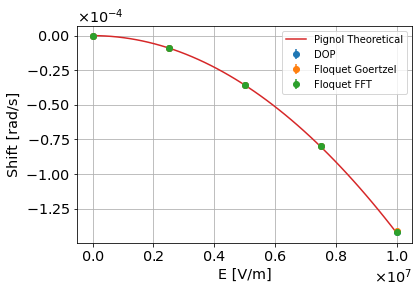

In [22]:
fig, ax = plt.subplots()
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['E'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

pred_x = compiled_data[compiled_data['iType'] == 0]['E']
pred_y = compiled_data[compiled_data['iType'] == 0]['expected_shift']
tx, ty = smooth_theory(pred_x, pred_y)
plt.plot(tx, ty,
        label='Pignol Theoretical')
ax.xaxis.set_major_formatter(get_formatter())  # Apply formatter to the x-axis
ax.yaxis.set_major_formatter(get_formatter())  # Apply formatter to the y-axis
plt.legend()
plt.grid()
plt.xlabel('E [V/m]')
plt.ylabel('Shift [rad/s]')
plt.savefig('E2_pignol.eps', bbox_inches='tight')

In [23]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, B2_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, B2_folder, 'out_*.hdf5')))
Gvalues = set(data['Gzz'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, gzz in itertools.product(iTypes, Gvalues):
    mask = (data['Gzz'] == gzz) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('Gzz', gzz)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('Gzz')
tf = compiled_data['tf'].iloc[0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


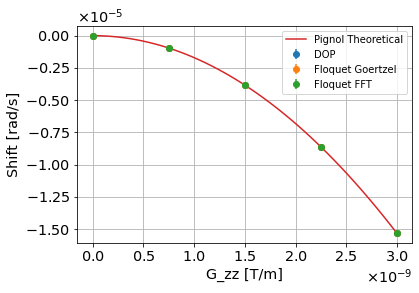

In [24]:
fig, ax = plt.subplots()
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['Gzz'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

pred_x = compiled_data[compiled_data['iType'] == 0]['Gzz']
pred_y = compiled_data[compiled_data['iType'] == 0]['expected_shift']
tx, ty = smooth_theory(pred_x, pred_y)
plt.plot(tx, ty,
        label='Pignol Theoretical')
ax.xaxis.set_major_formatter(get_formatter())  # Apply formatter to the x-axis
ax.yaxis.set_major_formatter(get_formatter())  # Apply formatter to the y-axis
plt.legend()
plt.xlabel('G_zz [T/m]')
plt.ylabel('Shift [rad/s]')
plt.grid()
plt.savefig('B2_pignol.eps', bbox_inches='tight')

In [17]:
EB_folder = 'EB_benchmark'

In [73]:
#integration['integratorType'] = '0'
#integration['ioutInt'] = '1.0'
#pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
#                                        executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, EB_folder))
#pb.run()
E_range = np.linspace(-1e6, 1e6, num=11)
parameter_tuples = [('0', '1.0'), ('6', '1.0'), ('7', '1.0')]
Gzz_range = [3e-10]
T_range = [0.25]
for _ in range(16):
    for (iType, ioutInt) in parameter_tuples:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                            E_range = E_range,
                                            Gzz_range = Gzz_range,
                                            T_range=T_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, EB_folder))
        pb.run()

iter 0, duration 0, 14
iter 1, duration 1, 698
{-8.82275e-06, -0.901828, 0.432095}
1070
 
iter 0, duration 0, 13
iter 1, duration 1, 682
{-1.42184e-06, -0.901828, 0.432095}
966
 
iter 0, duration 0, 13
iter 1, duration 1, 676
{2.15627e-06, -0.901828, 0.432096}
934
 
iter 0, duration 0, 13
iter 1, duration 1, 680
{1.1751e-06, -0.901828, 0.432096}
951
 
iter 0, duration 0, 14
iter 1, duration 1, 677
{-1.60556e-07, -0.901828, 0.432096}
946
 
iter 0, duration 0, 13
iter 1, duration 1, 674
{-3.12888e-07, -0.901827, 0.432096}
952
 
iter 0, duration 0, 12
iter 1, duration 1, 680
{2.90142e-07, -0.901828, 0.432096}
932
 
iter 0, duration 0, 12
iter 1, duration 1, 679
{-1.52148e-06, -0.901828, 0.432096}
935
 
iter 0, duration 0, 14
iter 1, duration 1, 684
{9.89822e-07, -0.901828, 0.432096}
958
 
iter 0, duration 0, 13
iter 1, duration 1, 669
{1.02418e-06, -0.901828, 0.432095}
948
 
iter 0, duration 0, 13
iter 1, duration 1, 683
{4.57886e-08, -0.901828, 0.432095}
968
 
iter 0, duration 0, 6
iter 

{4.86666e-13, -0.901828, 0.432096}
691
 
iter 0, duration 0, 99
iter 1, duration 1, 126
{4.86722e-13, -0.901827, 0.432096}
696
 
iter 0, duration 0, 100
iter 1, duration 1, 118
{4.86527e-13, -0.901828, 0.432096}
680
 
iter 0, duration 0, 99
iter 1, duration 1, 119
{4.86583e-13, -0.901828, 0.432096}
701
 
iter 0, duration 0, 101
iter 1, duration 1, 120
{4.86639e-13, -0.901828, 0.432096}
696
 
iter 0, duration 0, 102
iter 1, duration 1, 119
{4.86472e-13, -0.901828, 0.432095}
682
 
iter 0, duration 0, 99
iter 1, duration 1, 119
{4.86694e-13, -0.901828, 0.432095}
689
 
iter 0, duration 0, 13
iter 1, duration 1, 684
{-4.63604e-06, -0.901828, 0.432095}
955
 
iter 0, duration 0, 14
iter 1, duration 1, 672
{8.81362e-06, -0.901828, 0.432095}
931
 
iter 0, duration 0, 14
iter 1, duration 1, 681
{-3.55936e-06, -0.901828, 0.432096}
952
 
iter 0, duration 0, 12
iter 1, duration 1, 675
{-2.2778e-06, -0.901828, 0.432096}
937
 
iter 0, duration 0, 13
iter 1, duration 1, 673
{-7.69315e-07, -0.901828, 0

iter 1, duration 1, 2350
{4.8675e-13, -0.901828, 0.432095}
2635
 
iter 0, duration 0, 6
iter 1, duration 1, 2394
{4.86583e-13, -0.901828, 0.432095}
2662
 
iter 0, duration 0, 98
iter 1, duration 1, 120
{4.86666e-13, -0.901828, 0.432095}
691
 
iter 0, duration 0, 99
iter 1, duration 1, 118
{4.8675e-13, -0.901828, 0.432095}
679
 
iter 0, duration 0, 101
iter 1, duration 1, 119
{4.86777e-13, -0.901828, 0.432096}
694
 
iter 0, duration 0, 100
iter 1, duration 1, 119
{4.86694e-13, -0.901828, 0.432096}
686
 
iter 0, duration 0, 101
iter 1, duration 1, 119
{4.86583e-13, -0.901828, 0.432096}
685
 
iter 0, duration 0, 98
iter 1, duration 1, 128
{4.86583e-13, -0.901827, 0.432096}
707
 
iter 0, duration 0, 100
iter 1, duration 1, 118
{4.86639e-13, -0.901828, 0.432096}
699
 
iter 0, duration 0, 99
iter 1, duration 1, 118
{4.865e-13, -0.901828, 0.432096}
702
 
iter 0, duration 0, 102
iter 1, duration 1, 121
{4.86777e-13, -0.901828, 0.432096}
700
 
iter 0, duration 0, 100
iter 1, duration 1, 119
{4.

2657
 
iter 0, duration 0, 6
iter 1, duration 1, 2416
{4.86555e-13, -0.901828, 0.432096}
2697
 
iter 0, duration 0, 6
iter 1, duration 1, 2402
{4.86694e-13, -0.901827, 0.432096}
2677
 
iter 0, duration 0, 6
iter 1, duration 1, 2426
{4.86694e-13, -0.901827, 0.432096}
2688
 
iter 0, duration 0, 6
iter 1, duration 1, 2401
{4.86555e-13, -0.901828, 0.432096}
2667
 
iter 0, duration 0, 6
iter 1, duration 1, 2379
{4.86611e-13, -0.901828, 0.432096}
2642
 
iter 0, duration 0, 6
iter 1, duration 1, 2422
{4.86666e-13, -0.901828, 0.432096}
2682
 
iter 0, duration 0, 6
iter 1, duration 1, 2423
{4.86694e-13, -0.901828, 0.432095}
2703
 
iter 0, duration 0, 5
iter 1, duration 1, 2394
{4.86527e-13, -0.901828, 0.432095}
2658
 
iter 0, duration 0, 101
iter 1, duration 1, 119
{4.86639e-13, -0.901828, 0.432095}
699
 
iter 0, duration 0, 98
iter 1, duration 1, 119
{4.86611e-13, -0.901828, 0.432095}
683
 
iter 0, duration 0, 99
iter 1, duration 1, 120
{4.86722e-13, -0.901828, 0.432096}
707
 
iter 0, duration

{-1.60568e-06, -0.901828, 0.432096}
935
 
iter 0, duration 0, 14
iter 1, duration 1, 676
{-6.60491e-06, -0.901828, 0.432096}
946
 
iter 0, duration 0, 13
iter 1, duration 1, 674
{-6.36902e-06, -0.901828, 0.432095}
942
 
iter 0, duration 0, 12
iter 1, duration 1, 688
{8.92225e-06, -0.901828, 0.432095}
952
 
iter 0, duration 0, 6
iter 1, duration 1, 2416
{4.86722e-13, -0.901828, 0.432095}
2685
 
iter 0, duration 0, 6
iter 1, duration 1, 2381
{4.86694e-13, -0.901828, 0.432095}
2663
 
iter 0, duration 0, 6
iter 1, duration 1, 2381
{4.86416e-13, -0.901828, 0.432096}
2664
 
iter 0, duration 0, 6
iter 1, duration 1, 2383
{4.86722e-13, -0.901828, 0.432096}
2666
 
iter 0, duration 0, 5
iter 1, duration 1, 2381
{4.86694e-13, -0.901827, 0.432096}
2665
 
iter 0, duration 0, 6
iter 1, duration 1, 2410
{4.86666e-13, -0.901827, 0.432096}
2684
 
iter 0, duration 0, 6
iter 1, duration 1, 2362
{4.86639e-13, -0.901828, 0.432096}
2638
 
iter 0, duration 0, 5
iter 1, duration 1, 2426
{4.86583e-13, -0.90182

954
 
iter 0, duration 0, 12
iter 1, duration 1, 685
{-4.09718e-07, -0.901828, 0.432095}
952
 
iter 0, duration 0, 13
iter 1, duration 1, 678
{2.45321e-06, -0.901828, 0.432096}
941
 
iter 0, duration 0, 12
iter 1, duration 1, 679
{1.92718e-06, -0.901828, 0.432096}
935
 
iter 0, duration 0, 14
iter 1, duration 1, 692
{-4.36736e-07, -0.901828, 0.432096}
962
 
iter 0, duration 0, 14
iter 1, duration 1, 680
{-4.39449e-07, -0.901827, 0.432096}
944
 
iter 0, duration 0, 13
iter 1, duration 1, 686
{-5.72146e-07, -0.901828, 0.432096}
967
 
iter 0, duration 0, 12
iter 1, duration 1, 680
{2.38664e-06, -0.901828, 0.432096}
958
 
iter 0, duration 0, 14
iter 1, duration 1, 676
{-7.19668e-06, -0.901828, 0.432096}
958
 
iter 0, duration 0, 14
iter 1, duration 1, 684
{1.48996e-06, -0.901828, 0.432095}
953
 
iter 0, duration 0, 14
iter 1, duration 1, 678
{1.77101e-05, -0.901828, 0.432095}
947
 
iter 0, duration 0, 5
iter 1, duration 1, 2366
{4.865e-13, -0.901828, 0.432095}
2641
 
iter 0, duration 0, 6


In [25]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, EB_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, EB_folder, 'out_*.hdf5')))
Evalues = set(data['E'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = (data['E'] == ev) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('E')
tf = compiled_data['tf'].iloc[0]

In [26]:
c = benchmarks.Collector()
Evalues = set(np.abs(compiled_data['E']))
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = ((data['E'] == ev) | (data['E'] == -ev)) & (data['iType'] == it)
    mask_positive = (data['E'] == ev) & (data['iType'] == it)
    mask_negative = (data['E'] == -ev) & (data['iType'] == it)
    error_positive = benchmarks.phase_std(np.array(data[mask_positive]['phi']))/np.sqrt(len(data[mask_positive]))
    error_negative = benchmarks.phase_std(np.array(data[mask_negative]['phi']))/np.sqrt(len(data[mask_negative]))
    print
    true_phase_error = np.sqrt(error_positive**2 + error_negative**2)/2
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('iType', it)
    c.add('phase_error', true_phase_error)
    c.add('expected_shift', np.mean(data[mask]['expected_shift'] * np.sign(data[mask]['E'])))
    c.add('shift', np.mean(data[mask]['shift'] * np.sign(data[mask]['E'])))
EB_data = c.to_pandas().sort_values('E')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


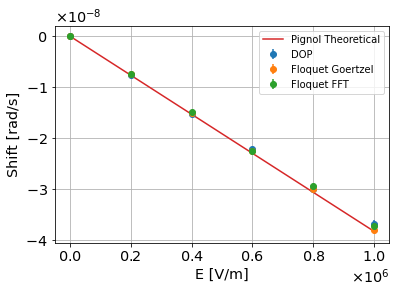

In [27]:
fig, ax = plt.subplots()
for it in iTypes:
    mask = EB_data['iType'] == it
    #print(compiled_data[mask].sort_values('E'))
    plt.errorbar(EB_data[mask]['E'], EB_data[mask]['shift'], yerr=EB_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

plt.plot(EB_data[EB_data['iType'] == 0]['E'], EB_data[EB_data['iType'] == 0]['expected_shift'],
        label='Pignol Theoretical')
ax.xaxis.set_major_formatter(get_formatter())  # Apply formatter to the x-axis
ax.yaxis.set_major_formatter(get_formatter())  # Apply formatter to the y-axis
plt.legend()
plt.xlabel('E [V/m]')
plt.ylabel('Shift [rad/s]')
plt.grid()
plt.savefig('EB_shift.eps', bbox_inches='tight')